In [ ]:
!pip install tabicl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.4/310.4 kB 11.7 MB/s eta 0:00:00


In [ ]:
import argparse
import numpy as np
import matplotlib.pyplot as plt

STAGE = "post_icl"          # 'post_icl' or 'pre_icl'

C0, C1, SHIFT, FLAG = "#3d6fb4", "#d1682e", "#7b3fb0", "#c0243c"


# --------------------------- extraction (needs TabICL) ---------------------------
def load_tabicl(device=None, random_state=0):
    from tabicl import TabICLClassifier
    return TabICLClassifier(
        n_estimators=1,        # single clean pass; no ensembling noise
        kv_cache=False,        # full train+test forward: retained rows are recomputed
        random_state=random_state,
        device=device,         # None -> auto (cpu / cuda / mps)
    )

def fit_pca(H, k=2):
    mean = H.mean(0)
    _, _, Vt = np.linalg.svd(H - mean, full_matrices=False)
    return mean, Vt[:k]

def apply_pca(H, mean, comps):
    return (H - mean) @ comps.T

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X_, y_ = make_classification(n_samples=60, n_features=6, n_informative=4,
                               n_redundant=0, n_classes=2, random_state=0)

X_ctx, X_eval, y_ctx, y_eval = train_test_split(
    X_, y_, test_size=0.2, random_state=0
)

X_ctx.shape

(48, 6)

In [ ]:
clf = load_tabicl()
clf.fit(X_ctx, y_ctx) # initiate the context

eval_proba = clf.predict_proba(X_eval)
eval_pred = clf.predict(X_eval)

INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.



tabicl-classifier-v2-20260212.ckpt: reconstructing file:   0%|          |  0.00B /  110MB            

tabicl-classifier-v2-20260212.ckpt: downloading bytes:           |  0.00B            

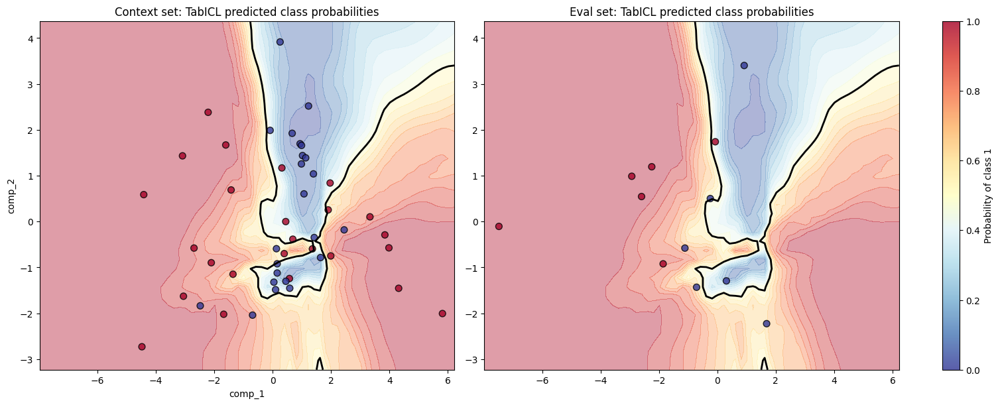

In [ ]:
mean, comp = fit_pca(X_)
x_2d = apply_pca(X_, mean, comp)
ctx_2d = apply_pca(X_ctx, mean, comp)
eval_2d = apply_pca(X_eval, mean, comp)

X = x_2d

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

# Create a mesh to plot decision boundaries
h = 0.2
offset = 0.5
x_min, x_max = X[:, 0].min() - offset, X[:, 0].max() + offset
y_min, y_max = X[:, 1].min() - offset, X[:, 1].max() + offset
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))


# Predict probabilities on mesh
grid_2d = np.c_[xx.ravel(), yy.ravel()]
grid = grid_2d @ comp + mean
Z = clf.predict_proba(grid)[:, 1]
Z = Z.reshape(xx.shape)

# Plot decision boundary and margins
ax[0].contourf(xx, yy, Z, levels=20, cmap="RdYlBu_r", alpha=0.4)
ax[0].contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)

scatter = ax[0].scatter(
    ctx_2d[:, 0],
    ctx_2d[:, 1],
    c=y_ctx,
    cmap="RdYlBu_r",
    edgecolors="k",
    s=50,
    alpha=0.8,
)

# Plot decision boundary and margins
ax[1].contourf(xx, yy, Z, levels=20, cmap="RdYlBu_r", alpha=0.4)
ax[1].contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)


eval_2d = apply_pca(X_eval, mean, comp)
ax[1].scatter(
    eval_2d[:, 0],
    eval_2d[:, 1],
    c=y_eval,
    cmap="RdYlBu_r",
    edgecolors="k",
    s=50,
    alpha=0.8,
)

ax[0].set(xlabel="comp_1", ylabel="comp_2")
ax[0].set_title("Context set: TabICL predicted class probabilities")
ax[1].set_title("Eval set: TabICL predicted class probabilities")
plt.colorbar(scatter, ax=ax, label="Probability of class 1")
cutplt.show()

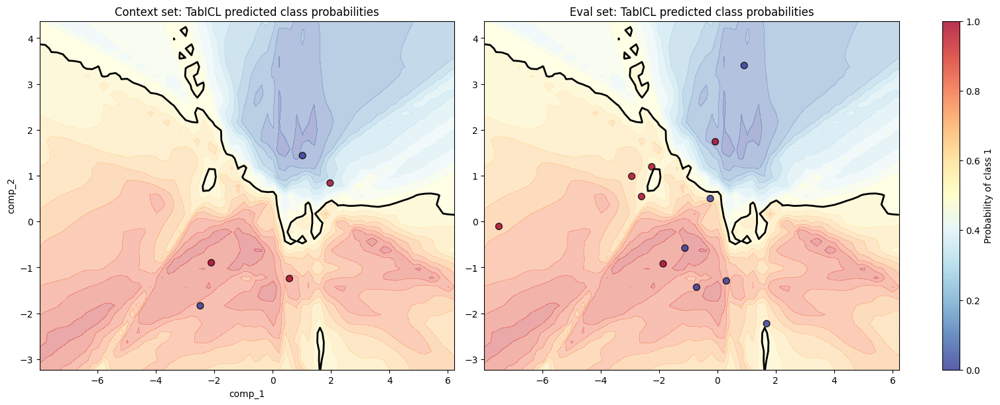

In [ ]:
ctx_n = 5
clf = load_tabicl()
clf.fit(X_ctx[:ctx_n], y_ctx[:ctx_n]) # initiate the context

eval_proba = clf.predict_proba(X_eval)
eval_pred = clf.predict(X_eval)

mean, comp = fit_pca(X_)
x_2d = apply_pca(X_, mean, comp)
ctx_2d = apply_pca(X_ctx[:ctx_n], mean, comp)
eval_2d = apply_pca(X_eval, mean, comp)

X = x_2d

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

# Create a mesh to plot decision boundaries
h = 0.2
offset = 0.5
x_min, x_max = X[:, 0].min() - offset, X[:, 0].max() + offset
y_min, y_max = X[:, 1].min() - offset, X[:, 1].max() + offset
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))


# Predict probabilities on mesh
grid_2d = np.c_[xx.ravel(), yy.ravel()]
grid = grid_2d @ comp + mean
Z = clf.predict_proba(grid)[:, 1]
Z = Z.reshape(xx.shape)

# Plot decision boundary and margins
ax[0].contourf(xx, yy, Z, levels=20, cmap="RdYlBu_r", alpha=0.4)
ax[0].contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)

scatter = ax[0].scatter(
    ctx_2d[:ctx_n, 0],
    ctx_2d[:ctx_n, 1],
    c=y_ctx[:ctx_n],
    cmap="RdYlBu_r",
    edgecolors="k",
    s=50,
    alpha=0.8,
)

# Plot decision boundary and margins
ax[1].contourf(xx, yy, Z, levels=20, cmap="RdYlBu_r", alpha=0.4)
ax[1].contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)


eval_2d = apply_pca(X_eval, mean, comp)
ax[1].scatter(
    eval_2d[:, 0],
    eval_2d[:, 1],
    c=y_eval,
    cmap="RdYlBu_r",
    edgecolors="k",
    s=50,
    alpha=0.8,
)

ax[0].set(xlabel="comp_1", ylabel="comp_2")
ax[0].set_title("Context set: TabICL predicted class probabilities")
ax[1].set_title("Eval set: TabICL predicted class probabilities")
plt.colorbar(scatter, ax=ax, label="Probability of class 1")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics.pairwise import cosine_similarity


# --------------------------- Deep Extraction ---------------------------
def extract_all_layers(clf, X_ctx, y_ctx, X_eval):
    X_ctx = np.asarray(X_ctx, float)
    y_ctx = np.asarray(y_ctx, int)
    X_eval = np.asarray(X_eval, float)

    n_ctx = len(X_ctx)
    expected_seq_len = n_ctx + len(X_eval)

    clf.fit(X_ctx, y_ctx)

    layer_embeddings = {}
    handles = []

    def make_hook(layer_name):
        def hook(m, inp, out):
            # The output might be a tensor, or a tuple of tensors
            tensors = [out] if isinstance(out, torch.Tensor) else (out if isinstance(out, tuple) else [])

            for tensor in tensors:
                if not isinstance(tensor, torch.Tensor):
                    continue

                t = tensor.detach().float().cpu().numpy()

                # Check if it has 3 dimensions (Batch, Seq, Dim) or (Seq, Batch, Dim)
                if t.ndim == 3:
                    # Squeeze out the batch dimension (assumed to be 1)
                    if t.shape[0] == 1:
                        t = t[0]          # -> (Seq, Dim)
                    elif t.shape[1] == 1:
                        t = t[:, 0, :]    # -> (Seq, Dim)

                    # If the sequence length matches our total rows, we caught a sequence layer!
                    if t.shape[0] == expected_seq_len:
                        layer_embeddings[layer_name] = t
        return hook

    # Hook EVERY submodule inside the model
    for name, module in clf.model_.named_modules():
        if name != "": # Skip the top-level wrapper to avoid duplicate tensors
            handles.append(module.register_forward_hook(make_hook(name)))

    # Trigger the forward pass
    try:
        clf.predict_proba(X_eval)
    finally:
        # Clean up memory
        for h in handles:
            h.remove()

    # Parse into Context vs. Eval
    parsed_embeddings = {}
    for name, emb in layer_embeddings.items():
        parsed_embeddings[name] = {
            "context": emb[:n_ctx, :],
            "eval": emb[n_ctx:, :],
            "full": emb
        }

    return parsed_embeddings

# --------------------------- Visualization ---------------------------
def plot_attention_proxy(embeddings_dict, layer_name, n_ctx):
    if layer_name not in embeddings_dict:
        print(f"Layer '{layer_name}' not found. Available layers: {list(embeddings_dict.keys())}")
        return

    # Grab the full sequence
    full_seq = embeddings_dict[layer_name]["full"]

    # Compute Cosine Similarity (Proxy for Attention QK^T)
    sim_matrix = cosine_similarity(full_seq)

    n_eval = len(full_seq) - n_ctx

    plt.figure(figsize=(8, 6))
    plt.imshow(sim_matrix, cmap='viridis', aspect='auto')
    plt.colorbar(label="Cosine Similarity")

    # Draw lines to separate Context and Query
    plt.axvline(x=n_ctx - 0.5, color='white', linestyle='--', lw=2)
    plt.axhline(y=n_ctx - 0.5, color='white', linestyle='--', lw=2)

    plt.title(f"Attention Proxy (Similarity) - Layer: {layer_name}")
    plt.xlabel("Sequence Index (Attending To)")
    plt.ylabel("Sequence Index (Attending From)")

    # Annotate quadrants
    plt.text(n_ctx/2, n_ctx/2, 'Ctx $\\leftrightarrow$ Ctx', color='white', ha='center', va='center')
    plt.text(n_ctx/2, n_ctx + n_eval/2, 'Query $\\rightarrow$ Ctx', color='white', ha='center', va='center')

    plt.tight_layout()
    plt.show()

In [ ]:
parsed_embeddings = extract_all_layers(clf, X_ctx, y_ctx, X_eval)
print(f"Extracted {len(parsed_embeddings)} valid sequence layers.")
# Print out the actual names of the layers we found!
layer_names = list(parsed_embeddings.keys())
# print("\nFound Layers:")
for name in layer_names:
   print(f" - {name}")

Extracted 115 valid sequence layers.
 - row_interactor
 - icl_predictor.tf_icl.blocks.0.norm1
 - icl_predictor.tf_icl.blocks.0.attn
 - icl_predictor.tf_icl.blocks.0.dropout1
 - icl_predictor.tf_icl.blocks.0.norm2
 - icl_predictor.tf_icl.blocks.0.linear1
 - icl_predictor.tf_icl.blocks.0.dropout
 - icl_predictor.tf_icl.blocks.0.linear2
 - icl_predictor.tf_icl.blocks.0.dropout2
 - icl_predictor.tf_icl.blocks.0
 - icl_predictor.tf_icl.blocks.1.norm1
 - icl_predictor.tf_icl.blocks.1.attn
 - icl_predictor.tf_icl.blocks.1.dropout1
 - icl_predictor.tf_icl.blocks.1.norm2
 - icl_predictor.tf_icl.blocks.1.linear1
 - icl_predictor.tf_icl.blocks.1.dropout
 - icl_predictor.tf_icl.blocks.1.linear2
 - icl_predictor.tf_icl.blocks.1.dropout2
 - icl_predictor.tf_icl.blocks.1
 - icl_predictor.tf_icl.blocks.2.norm1
 - icl_predictor.tf_icl.blocks.2.attn
 - icl_predictor.tf_icl.blocks.2.dropout1
 - icl_predictor.tf_icl.blocks.2.norm2
 - icl_predictor.tf_icl.blocks.2.linear1
 - icl_predictor.tf_icl.blocks.2.d

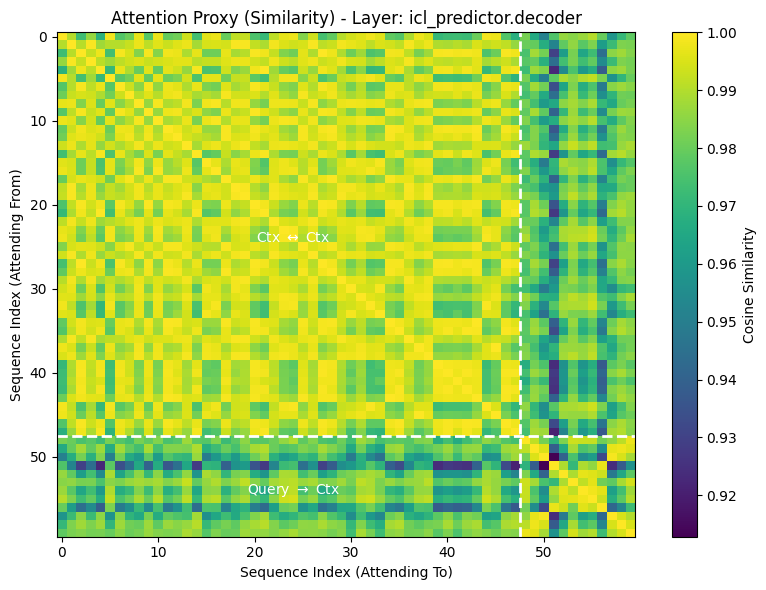

In [ ]:
if layer_names:
  last_layer = layer_names[-1]
  plot_attention_proxy(parsed_embeddings, layer_name=last_layer, n_ctx=len(X_ctx))

In [ ]:
 # ================== Shrinking-context TabICL animation (Colab-ready) ==================
# Paste into a cell and run. Needs: tabicl, torch, numpy, matplotlib, scikit-learn.

# ----------------------------- config (edit me) -----------------------------
DEMO        = False   # True = Gaussian-process stand-in (no TabICL) to test the plot
MIN_CTX     = 5       # stop when the context has this many points
STEP        = 1       # context points removed per frame
GRID_H      = 0.3     # mesh resolution (raise to 0.4 to go faster)
FPS         = 2       # GIF speed if SAVE_GIF (lower = slower)
INTERVAL_MS = 700     # inline player: milliseconds per frame (higher = slower)
SAVE_GIF    = True   # also write a .gif file
OUT         = "context_shrink.gif"

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
plt.rcParams["animation.embed_limit"] = 200   # MB budget for inline HTML

CMAP, CMAP_ATT = "RdYlBu_r", "magma"

# -------- TabICL loader + embedding extractor (swap load_tabicl for yours if you like) --------
def load_tabicl():
    from tabicl import TabICLClassifier
    return TabICLClassifier(n_estimators=1, kv_cache=False, random_state=0)

def extract_embeddings(clf, X_ctx, y_ctx, X_eval):
    """Fit on (X_ctx, y_ctx); return the ICL representation for X_eval rows."""
    import torch  # noqa: F401
    X_ctx = np.asarray(X_ctx, float); y_ctx = np.asarray(y_ctx); X_eval = np.asarray(X_eval, float)
    clf.fit(X_ctx, y_ctx)
    grabbed = []
    handle = clf.model_.icl_predictor.decoder.register_forward_pre_hook(
        lambda m, inp: grabbed.append(inp[0].detach().float().cpu().numpy()))
    try:
        clf.predict_proba(X_eval)
    finally:
        handle.remove()
    return grabbed[0][0, len(X_ctx):, :].astype(float)   # rows = X_eval, in order

# ------------------------------- helpers -------------------------------
def fit_pca(H, k=2):
    mean = H.mean(0); _, _, Vt = np.linalg.svd(H - mean, full_matrices=False)
    return mean, Vt[:k]

def apply_pca(H, mean, comp):
    return (H - mean) @ comp.T

def _sqdist(A, B):
    a = np.einsum("ij,ij->i", A, A)[:, None]; b = np.einsum("ij,ij->i", B, B)[None, :]
    return np.maximum(a + b - 2.0 * A @ B.T, 0.0)

def attention_map(h_eval, h_ctx, gamma=None):
    d2 = _sqdist(h_eval, h_ctx)
    if gamma is None:
        dd = _sqdist(h_ctx, h_ctx); off = dd[~np.eye(len(h_ctx), dtype=bool)]
        med = np.median(off[off > 0]) if np.any(off > 0) else 1.0
        gamma = 1.0 / (med + 1e-12)
    K = np.exp(-gamma * d2)
    return K / K.sum(1, keepdims=True)

def make_model(demo):
    if demo:
        from sklearn.gaussian_process import GaussianProcessClassifier
        from sklearn.gaussian_process.kernels import RBF
        return GaussianProcessClassifier(1.0 * RBF(2.0), random_state=0)
    return load_tabicl()

# ------------------------------- build frames -------------------------------
def build(demo, min_ctx, step, grid_h):
    from sklearn.datasets import make_classification
    from sklearn.model_selection import train_test_split
    X_, y_ = make_classification(n_samples=60, n_features=6, n_informative=4,
                                 n_redundant=0, n_classes=2, random_state=0)
    X_ctx, X_eval, y_ctx, y_eval = train_test_split(X_, y_, test_size=0.2, random_state=0)
    full = len(X_ctx)

    mean, comp = fit_pca(X_)
    ctx_2d, eval_2d, X2d = apply_pca(X_ctx, mean, comp), apply_pca(X_eval, mean, comp), apply_pca(X_, mean, comp)
    off = 0.5
    xx, yy = np.meshgrid(np.arange(X2d[:, 0].min() - off, X2d[:, 0].max() + off, grid_h),
                         np.arange(X2d[:, 1].min() - off, X2d[:, 1].max() + off, grid_h))
    grid = np.c_[xx.ravel(), yy.ravel()] @ comp + mean

    ns = list(range(full, min_ctx - 1, -step))
    if ns[-1] != min_ctx:
        ns.append(min_ctx)

    model = make_model(demo)
    Z_frames, att_frames, eval_traj = [], [], np.zeros((len(X_eval), len(ns)))
    for j, n in enumerate(ns):
        if demo:
            model.fit(X_ctx[:n], y_ctx[:n])
            W = attention_map(X_eval, X_ctx[:n])                        # feature-space stand-in
        else:
            h = extract_embeddings(model, X_ctx[:n], y_ctx[:n], np.vstack([X_ctx[:n], X_eval]))
            W = attention_map(h[n:], h[:n])                             # eval x context (embeddings)
        Z_frames.append(model.predict_proba(grid)[:, 1].reshape(xx.shape))
        eval_traj[:, j] = model.predict_proba(X_eval)[:, 1]
        att_frames.append(W)
        print(f"  frame {j+1}/{len(ns)}  context n={n}")
    return dict(xx=xx, yy=yy, Z=Z_frames, ns=ns, full=full, min_ctx=min_ctx,
                ctx_2d=ctx_2d, eval_2d=eval_2d, y_ctx=y_ctx, y_eval=y_eval,
                eval_traj=eval_traj, att=att_frames, att_vmax=max(float(W.max()) for W in att_frames))

# ------------------------------- animation -------------------------------
def make_animation(data, interval_ms):
    xx, yy, Z, ns = data["xx"], data["yy"], data["Z"], data["ns"]
    ctx_2d, eval_2d, y_ctx, y_eval = data["ctx_2d"], data["eval_2d"], data["y_ctx"], data["y_eval"]
    full, min_ctx, traj, att = data["full"], data["min_ctx"], data["eval_traj"], data["att"]
    n_eval = len(eval_2d)
    pnorm = Normalize(0, 1); levels = np.linspace(0, 1, 21)
    anorm = Normalize(0, data["att_vmax"]); ncol = {0: "#2c7bb6", 1: "#d7191c"}

    fig, ax = plt.subplots(1, 4, figsize=(23, 5.8), constrained_layout=True)
    fig.colorbar(ScalarMappable(norm=pnorm, cmap=CMAP), ax=ax[:2], label="P(class 1)",
                 fraction=0.025, pad=0.01)
    fig.colorbar(ScalarMappable(norm=anorm, cmap=CMAP_ATT), ax=ax[2], label="attention weight",
                 fraction=0.046, pad=0.02)

    def field(a, f):
        a.contourf(xx, yy, Z[f], levels=levels, cmap=CMAP, norm=pnorm, alpha=0.5)
        a.contour(xx, yy, Z[f], levels=[0.5], colors="black", linewidths=2)

    def update(f):
        for a in ax:
            a.clear()
        n = ns[f]
        field(ax[0], f)
        ax[0].scatter(ctx_2d[:n, 0], ctx_2d[:n, 1], c=y_ctx[:n], cmap=CMAP, norm=pnorm,
                      edgecolors="k", s=70, alpha=0.9, zorder=3)
        ax[0].set_title(f"Context set — n={n}"); ax[0].set(xlabel="comp_1", ylabel="comp_2")

        field(ax[1], f)
        ax[1].scatter(eval_2d[:, 0], eval_2d[:, 1], c=y_eval, cmap=CMAP, norm=pnorm,
                      edgecolors="k", s=70, alpha=0.9, zorder=3)
        for i, (px, py) in enumerate(eval_2d):
            ax[1].annotate(str(i), (px, py), textcoords="offset points", xytext=(6, 5),
                           fontsize=9, fontweight="bold", zorder=4)
        ax[1].set_title(f"Eval set — n={n}"); ax[1].set(xlabel="comp_1")

        ax[2].imshow(att[f], aspect="auto", cmap=CMAP_ATT, norm=anorm, origin="upper")
        ax[2].set_yticks(range(n_eval)); ax[2].set_yticklabels(range(n_eval), fontsize=7)
        ax[2].set_title(f"Eval \u2192 context attention — n={n}")
        ax[2].set(xlabel="context point", ylabel="eval point")

        xs = ns[:f + 1]
        for i in range(n_eval):
            ax[3].plot(xs, traj[i, :f + 1], color=ncol[int(y_eval[i])], lw=1.3, alpha=0.8)
            ax[3].annotate(str(i), (xs[-1], traj[i, f]), textcoords="offset points",
                           xytext=(4, 0), fontsize=8, fontweight="bold", color=ncol[int(y_eval[i])])
        ax[3].axhline(0.5, color="k", lw=1, ls="--", alpha=0.6)
        ax[3].set_xlim(full, min_ctx); ax[3].set_ylim(-0.02, 1.02)
        ax[3].set_title("Predicted P(class 1) trajectory")
        ax[3].set(xlabel="context size (shrinking \u2192)", ylabel="P(class 1)")
        return []

    anim = FuncAnimation(fig, update, frames=len(ns), interval=interval_ms, blit=False)
    return anim, fig

# ------------------------------- run -------------------------------
data = build(demo=DEMO, min_ctx=MIN_CTX, step=STEP, grid_h=GRID_H)
anim, fig = make_animation(data, interval_ms=INTERVAL_MS)
if SAVE_GIF:
    anim.save(OUT, writer=PillowWriter(fps=FPS)); print("wrote", OUT)
plt.close(fig)   # stop the static first frame from also showing in the notebook

from IPython.display import HTML
HTML(anim.to_jshtml())   # <- inline player in Colab (slowed by INTERVAL_MS)

  frame 1/44  context n=48
  frame 2/44  context n=47
  frame 3/44  context n=46
  frame 4/44  context n=45
  frame 5/44  context n=44
  frame 6/44  context n=43
  frame 7/44  context n=42
  frame 8/44  context n=41
  frame 9/44  context n=40
  frame 10/44  context n=39
  frame 11/44  context n=38
  frame 12/44  context n=37
  frame 13/44  context n=36
  frame 14/44  context n=35
  frame 15/44  context n=34
  frame 16/44  context n=33
  frame 17/44  context n=32
  frame 18/44  context n=31
  frame 19/44  context n=30
  frame 20/44  context n=29
  frame 21/44  context n=28
  frame 22/44  context n=27
  frame 23/44  context n=26
  frame 24/44  context n=25
  frame 25/44  context n=24
  frame 26/44  context n=23
  frame 27/44  context n=22
  frame 28/44  context n=21
  frame 29/44  context n=20
  frame 30/44  context n=19
  frame 31/44  context n=18
  frame 32/44  context n=17
  frame 33/44  context n=16
  frame 34/44  context n=15
  frame 35/44  context n=14
  frame 36/44  context n=13
 